#  SkinSight AI — 01 · Exploration du dataset

Ce notebook explore la structure du dataset, la distribution des classes,
et affiche des exemples d'images pour chaque pathologie.

**Classes :** `saine` · `acne_inflammatoire` · `acne_non_inflammatoire` · `rosacee` · `hyperpigmentation`

In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Racine du projet
BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR  = os.path.join(BASE_DIR, 'data')

CLASSES = ['saine', 'acne_inflammatoire', 'acne_non_inflammatoire', 'rosacee', 'hyperpigmentation']
SPLITS  = ['train', 'val', 'test']

# Palette couleurs projet
COLORS = ['#C07A5A', '#8B6A8B', '#D4A896', '#7A9E7E', '#B8956A']

print(f'BASE_DIR : {BASE_DIR}')
print(f'DATA_DIR : {DATA_DIR}')

BASE_DIR : c:\Users\nasri\OneDrive\Desktop\Projects\SkinSightAI
DATA_DIR : c:\Users\nasri\OneDrive\Desktop\Projects\SkinSightAI\data


<!-- ## 1. Structure du dataset -->

In [29]:
# Comptage des images par split et par classe
counts = {}
total  = 0

print(f"{'Classe':<30} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print('-' * 60)

for cls in CLASSES:
    counts[cls] = {}
    for split in SPLITS:
        path = os.path.join(DATA_DIR, split, cls)
        n = len(os.listdir(path)) if os.path.exists(path) else 0
        counts[cls][split] = n
    row_total = sum(counts[cls].values())
    total += row_total
    print(f'{cls:<30} {counts[cls]["train"]:>8} {counts[cls]["val"]:>8} {counts[cls]["test"]:>8} {row_total:>8}')

print('-' * 60)
train_t = sum(counts[c]['train'] for c in CLASSES)
val_t   = sum(counts[c]['val']   for c in CLASSES)
test_t  = sum(counts[c]['test']  for c in CLASSES)
print(f"{'TOTAL':<30} {train_t:>8} {val_t:>8} {test_t:>8} {total:>8}")

Classe                            Train      Val     Test    Total
------------------------------------------------------------
saine                                 0        0        0        0
acne_inflammatoire                    0        0        0        0
acne_non_inflammatoire                0        0        0        0
rosacee                               0        0        0        0
hyperpigmentation                     0        0        0        0
------------------------------------------------------------
TOTAL                                 0        0        0        0


<!-- ## 2. Distribution des classes -->

In [37]:
# Racine du projet
BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR  = os.path.join(BASE_DIR, 'data')

#  Choisir la source : 'raw' ou 'augmented'
IMAGE_SOURCE = 'augmented'  #  Change to 'raw' if needed

CLASSES = ['saine', 'acne_inflammatoire', 'acne_non_inflammatoire', 'rosacee', 'hyperpigmentation']
SPLITS  = ['train', 'val', 'test']

# Palette couleurs projet
COLORS = ['#C07A5A', '#8B6A8B', '#D4A896', '#7A9E7E', '#B8956A']

print(f'BASE_DIR : {BASE_DIR}')
print(f'DATA_DIR : {DATA_DIR}')
print(f'IMAGE_SOURCE : {IMAGE_SOURCE}')

# Comptage des images par split et par classe
counts = {}
total  = 0

print(f"{'Classe':<30} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print('-' * 60)

for cls in CLASSES:
    counts[cls] = {}
    for split in SPLITS:
        path = os.path.join(DATA_DIR, IMAGE_SOURCE, split, cls)
        n = len(os.listdir(path)) if os.path.exists(path) else 0
        counts[cls][split] = n
    row_total = sum(counts[cls].values())
    total += row_total
    print(f'{cls:<30} {counts[cls]["train"]:>8} {counts[cls]["val"]:>8} {counts[cls]["test"]:>8} {row_total:>8}')

print('-' * 60)
train_t = sum(counts[c]['train'] for c in CLASSES)
val_t   = sum(counts[c]['val']   for c in CLASSES)
test_t  = sum(counts[c]['test']  for c in CLASSES)
print(f"{'TOTAL':<30} {train_t:>8} {val_t:>8} {test_t:>8} {total:>8}")

BASE_DIR : c:\Users\nasri\OneDrive\Desktop\Projects\SkinSightAI
DATA_DIR : c:\Users\nasri\OneDrive\Desktop\Projects\SkinSightAI\data
IMAGE_SOURCE : augmented
Classe                            Train      Val     Test    Total
------------------------------------------------------------
saine                                 0        0        0        0
acne_inflammatoire                    0        0        0        0
acne_non_inflammatoire                0        0        0        0
rosacee                               0        0        0        0
hyperpigmentation                     0        0        0        0
------------------------------------------------------------
TOTAL                                 0        0        0        0


<!-- ## 3. Exemples d'images par classe -->

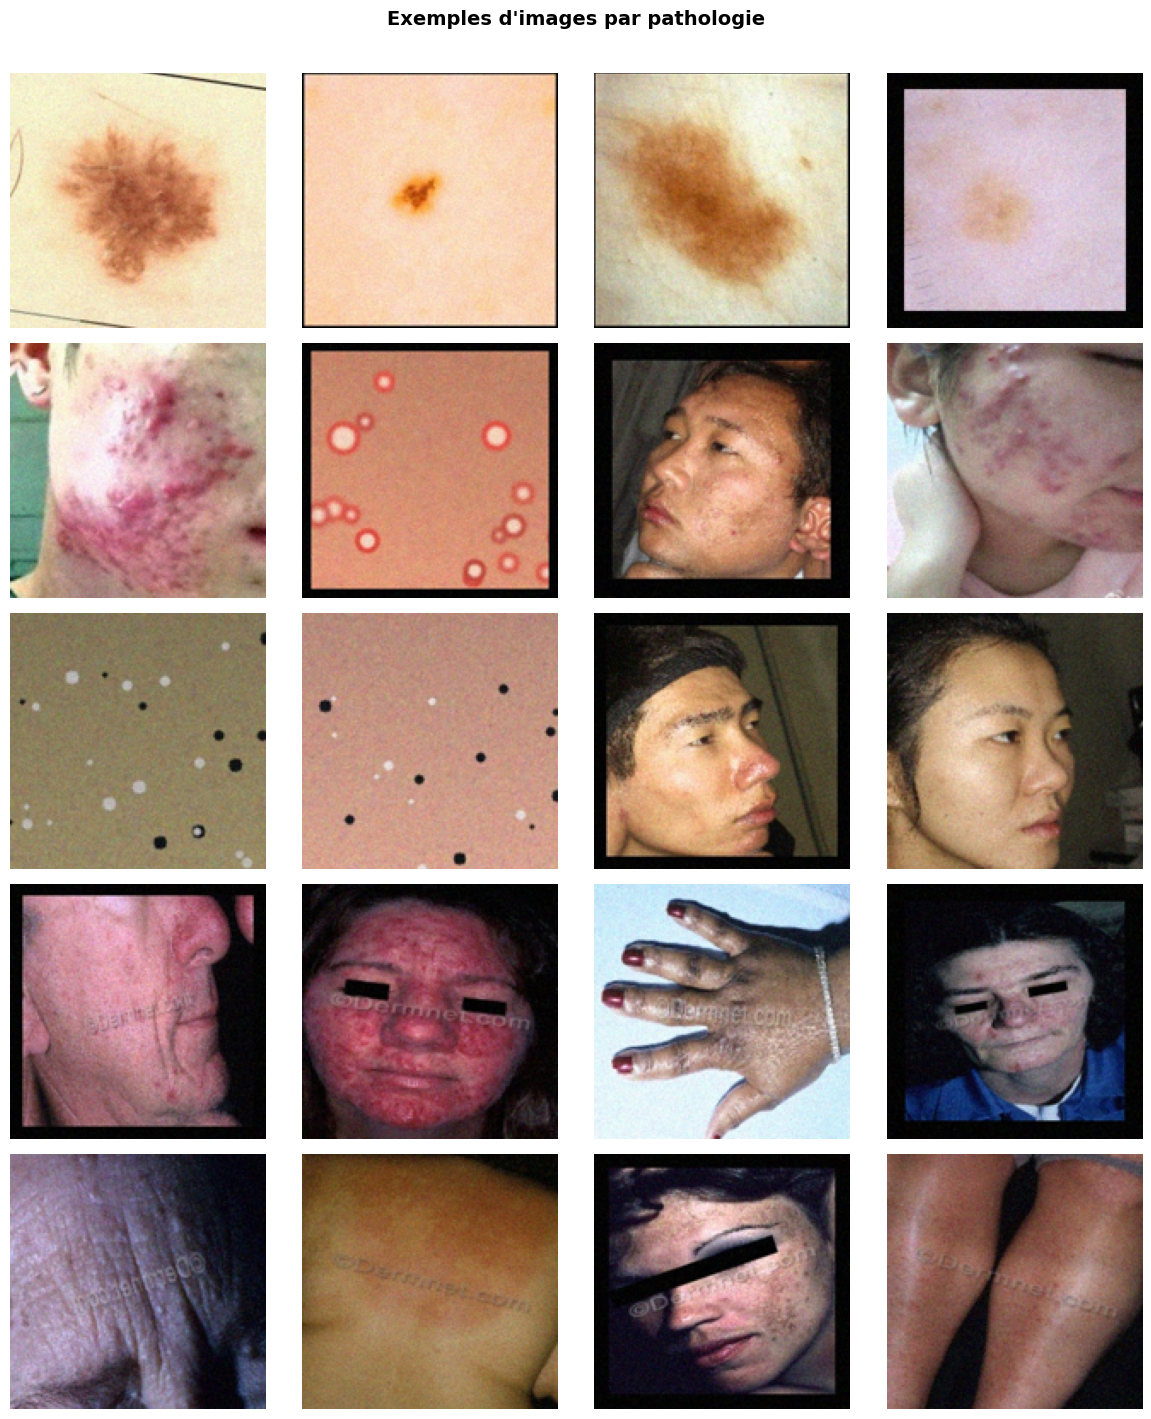

 Figure sauvegardée : fig_01_exemples.png


In [40]:
N_EXEMPLES = 4

#  Choisir la source : 'raw' ou 'augmented'
IMAGE_SOURCE = 'augmented'  # ← Change en 'raw' si tu veux les images brutes

fig, axes = plt.subplots(len(CLASSES), N_EXEMPLES, figsize=(12, 14))
fig.suptitle("Exemples d'images par pathologie", fontsize=14, fontweight='bold', y=1.01)

for i, cls in enumerate(CLASSES):
    
    folder = os.path.join(DATA_DIR, IMAGE_SOURCE, cls)
    
    if not os.path.exists(folder):
        print(f" Dossier non trouvé : {folder}")
        for j in range(N_EXEMPLES):
            axes[i, j].axis('off')
        continue
        
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    
    if len(files) == 0:
        print(f" Aucune image dans : {folder}")
        for j in range(N_EXEMPLES):
            axes[i, j].axis('off')
        continue
    
    np.random.seed(42)
    sample = np.random.choice(files, min(N_EXEMPLES, len(files)), replace=False)
    
    for j, fname in enumerate(sample):
        img = Image.open(os.path.join(folder, fname)).convert('RGB').resize((150, 150))
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(cls.replace('_', '\n'), fontsize=10,
                                   rotation=0, labelpad=70, va='center',
                                   color=COLORS[i], fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'notebooks', 'fig_01_exemples.png'), dpi=150, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée : fig_01_exemples.png')

<!-- ## 4. Analyse des dimensions d'images -->

Largeur  — min: 224px  max: 224px  moyenne: 224px
Hauteur  — min: 224px  max: 224px  moyenne: 224px


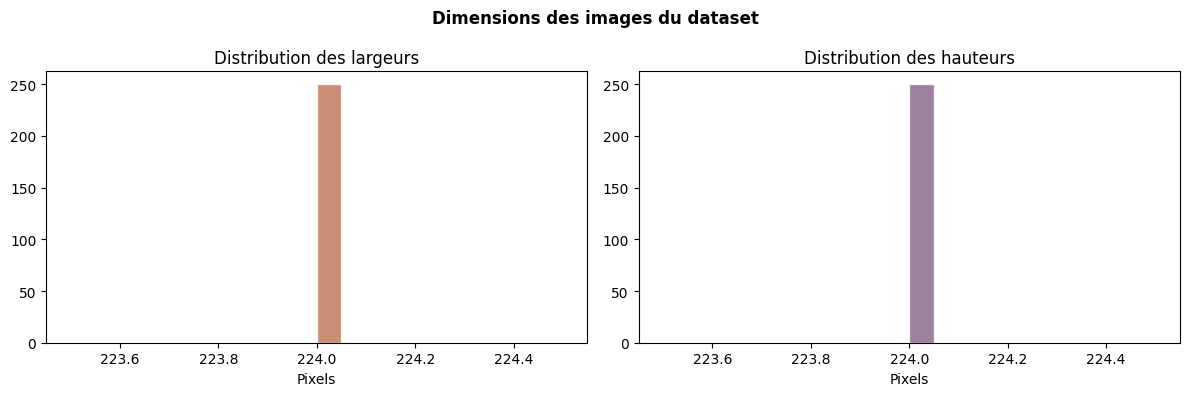

 Figure sauvegardée : fig_01_dimensions.png


In [42]:
widths, heights = [], []
sample_size = 50
IMAGE_SOURCE = 'augmented'  

for cls in CLASSES:
    folder = os.path.join(DATA_DIR, IMAGE_SOURCE, cls)
    if not os.path.exists(folder):
        print(f"️ Dossier ignoré : {folder}")
        continue
        
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if not files:
        continue
        
    np.random.seed(0)
    sample = np.random.choice(files, min(sample_size, len(files)), replace=False)
    
    for fname in sample:
        try:
            img = Image.open(os.path.join(folder, fname))
            widths.append(img.width)
            heights.append(img.height)
        except Exception as e:
            print(f"️ Erreur lecture {fname}: {e}")

#  Sécurité : éviter min()/max() sur liste vide
if not widths:
    print(" Aucune image lue. Vérifie que IMAGE_SOURCE pointe vers le bon dossier ('raw' ou 'augmented').")
else:
    print(f'Largeur  — min: {min(widths)}px  max: {max(widths)}px  moyenne: {np.mean(widths):.0f}px')
    print(f'Hauteur  — min: {min(heights)}px  max: {max(heights)}px  moyenne: {np.mean(heights):.0f}px')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(widths,  bins=20, color='#C07A5A', edgecolor='white', alpha=0.85)
    axes[0].set_title('Distribution des largeurs'); axes[0].set_xlabel('Pixels')
    axes[1].hist(heights, bins=20, color='#8B6A8B', edgecolor='white', alpha=0.85)
    axes[1].set_title('Distribution des hauteurs'); axes[1].set_xlabel('Pixels')
    plt.suptitle('Dimensions des images du dataset', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'notebooks', 'fig_01_dimensions.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(' Figure sauvegardée : fig_01_dimensions.png')

<!-- ## 5. Visualisation de l'augmentation -->

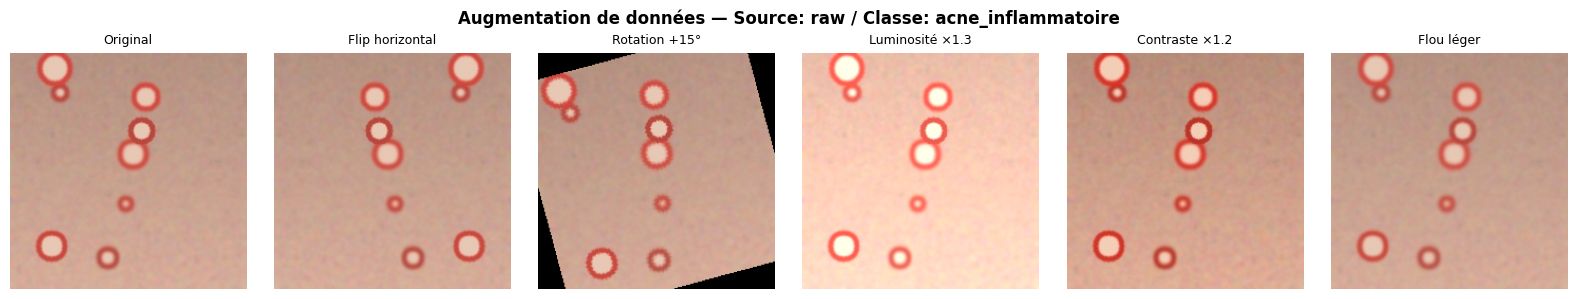

In [45]:
from PIL import ImageEnhance, ImageFilter
import os

#  On utilise 'raw' pour prendre une image propre avant augmentation
IMAGE_SOURCE = 'raw'  

cls_demo = 'acne_inflammatoire'
folder   = os.path.join(DATA_DIR, IMAGE_SOURCE, cls_demo)

if not os.path.exists(folder):
    raise FileNotFoundError(f"Dossier non trouvé : {folder}")

files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]

if not files:
    raise FileNotFoundError(f"Aucune image trouvée dans : {folder}")

# Charger l'image originale
img_orig = Image.open(os.path.join(folder, files[0])).convert('RGB').resize((224, 224))

# Transformations appliquées lors de l'augmentation
augmentations = [
    ('Original',          img_orig),
    ('Flip horizontal',   img_orig.transpose(Image.FLIP_LEFT_RIGHT)),
    ('Rotation +15°',     img_orig.rotate(15)),
    ('Luminosité ×1.3',   ImageEnhance.Brightness(img_orig).enhance(1.3)),
    ('Contraste ×1.2',    ImageEnhance.Contrast(img_orig).enhance(1.2)),
    ('Flou léger',        img_orig.filter(ImageFilter.GaussianBlur(1))),
]

fig, axes = plt.subplots(1, len(augmentations), figsize=(16, 3))
fig.suptitle(f'Augmentation de données — Source: {IMAGE_SOURCE} / Classe: {cls_demo}', fontweight='bold')
for ax, (title, img) in zip(axes, augmentations):
    ax.imshow(img); ax.set_title(title, fontsize=9); ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'notebooks', 'fig_01_augmentation.png'), dpi=150, bbox_inches='tight')
plt.show()

##  Résumé

| Métrique | Valeur |
|----------|--------|
| Classes  | 5 pathologies |
| Split train | ~5 000 images (après augmentation, 1000/classe) |
| Split val   | ~588 images |
| Split test  | ~591 images |
| Format cible | 224×224 px (MobileNetV2 / DenseNet) · 299×299 (InceptionV3) |

> **Note :** L'augmentation (flip, rotation, luminosité) a permis d'équilibrer les classes
> et d'atteindre 1000 images/classe en train, compensant le déséquilibre initial
> (ex. `acne_non_inflammatoire` n'avait que 497 images originales).

<!-- ##  Résumé

| Métrique | Valeur |
|----------|--------|
| Classes  | 5 pathologies |
| Split train | ~5 000 images (après augmentation, 1000/classe) |
| Split val   | ~588 images |
| Split test  | ~591 images |
| Format cible | 224×224 px (MobileNetV2 / DenseNet) · 299×299 (InceptionV3) |

> **Note :** L'augmentation (flip, rotation, luminosité) a permis d'équilibrer les classes
> et d'atteindre 1000 images/classe en train, compensant le déséquilibre initial
> (ex. `acne_non_inflammatoire` n'avait que 497 images originales). -->